# Autonomous RAG 

This RAG system is more agentic than basic RAG.

Instead of doing:

Question → Retrieve → Answer

It does:

Question
→ Plan subtasks
→ Select tools
→ Retrieve from tools
→ Synthesize answer
→ Reflect on answer
→ Retry if needed
→ Final answer


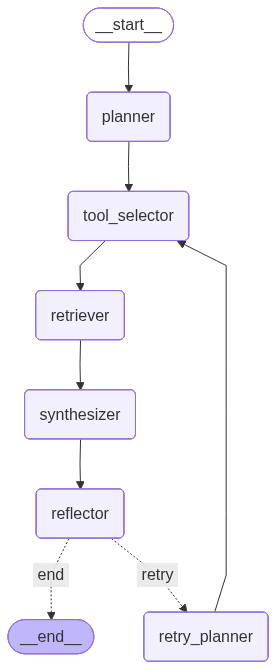

In [16]:
# %%
import os
from typing import Dict, List, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.utilities import WikipediaAPIWrapper

from langgraph.graph import StateGraph, START, END

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

llm = ChatGroq(model="qwen/qwen3-32b")

In [17]:

# 1. Document Processing 

urls = [
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/integrations/providers/overview"
]

docs = []

for url in urls:
    loader = WebBaseLoader(url)
    docs.extend(loader.load())

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

split_docs = splitter.split_documents(docs)



In [18]:
# 2. Build Vector DB
embedding = OpenAIEmbeddings()

vectorstore = FAISS.from_documents(split_docs, embedding)
vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

In [19]:

# 3. External Tool: Wikipedia

wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=1500)

In [5]:

# 4. LangGraph State Creation

class AutonomousRAGState(BaseModel):
    question: str

    subtasks: List[str] = Field(default_factory=list)

    selected_tools: Dict[str, str] = Field(default_factory=dict)
    retrieved_docs: Dict[str, List[str]] = Field(default_factory=dict)

    answer: str = ""
    reflection: str = ""

    attempts: int = 0
    max_attempts: int = 2

In [6]:
# Create Nodes


# 5. Planner Agent

def planner_agent(state: AutonomousRAGState) -> AutonomousRAGState:
    prompt = f"""
You are a planner agent for an autonomous RAG system.

Break the user's complex question into smaller retrieval subtasks.

User question:
{state.question}

Rules:
- Return each subtask on a new line.
- Do not number the subtasks.
- Do not explain.
- Keep each subtask short and searchable.
"""

    response = llm.invoke(prompt).content.strip()

    subtasks = [
        line.strip("- ").strip()
        for line in response.split("\n")
        if line.strip()
    ]

    state.subtasks = subtasks
    return state

In [7]:

# 6. Tool Selector Agent

def tool_selector_agent(state: AutonomousRAGState) -> AutonomousRAGState:
    selected_tools = {}

    for subtask in state.subtasks:
        prompt = f"""
You are a tool selector agent.

Choose the best tool for this subtask.

Available tools:

1. vector_db
- Use for LangChain, LangGraph, RAG, agents, model providers, internal docs.

2. wikipedia
- Use for general knowledge, concepts, people, companies, history, science.

Subtask:
{subtask}

Return only one word:
vector_db
or
wikipedia
"""

        tool = llm.invoke(prompt).content.strip().lower()

        if "wiki" in tool:
            selected_tools[subtask] = "wikipedia"
        else:
            selected_tools[subtask] = "vector_db"

    state.selected_tools = selected_tools
    return state

In [8]:
# 7. Retriever / Tool Executor

def retriever_agent(state: AutonomousRAGState) -> AutonomousRAGState:
    retrieved_docs = {}

    for subtask, tool in state.selected_tools.items():

        if tool == "vector_db":
            docs = vector_retriever.invoke(subtask)
            retrieved_docs[subtask] = [
                doc.page_content for doc in docs
            ]

        elif tool == "wikipedia":
            try:
                result = wiki.run(subtask)
                retrieved_docs[subtask] = [result]
            except Exception as e:
                retrieved_docs[subtask] = [
                    f"Wikipedia retrieval failed: {str(e)}"
                ]

    state.retrieved_docs = retrieved_docs
    return state

In [9]:

# 8. Synthesizer Agent

def synthesizer_agent(state: AutonomousRAGState) -> AutonomousRAGState:
    context = ""

    for subtask, docs in state.retrieved_docs.items():
        context += f"\n\nSubtask: {subtask}\n"
        for doc in docs:
            context += f"- {doc}\n"

    prompt = f"""
You are a synthesizer agent.

Use the retrieved context to answer the original user question.

Original question:
{state.question}

Retrieved context:
{context}

Instructions:
- Combine information from all subtasks.
- Answer clearly and completely.
- Do not hallucinate.
- If the retrieved context is insufficient, say what is missing.

Final answer:
"""

    state.answer = llm.invoke(prompt).content.strip()
    return state

In [10]:

# 9. Reflector Agent

def reflector_agent(state: AutonomousRAGState) -> AutonomousRAGState:
    context = ""

    for subtask, docs in state.retrieved_docs.items():
        context += f"\n\nSubtask: {subtask}\n"
        for doc in docs:
            context += f"- {doc[:700]}\n"

    prompt = f"""
You are a strict reflection agent.

Evaluate whether the generated answer is good enough.

Original question:
{state.question}

Retrieved context:
{context}

Generated answer:
{state.answer}

Return PASS if:
- The answer directly answers the original question.
- The answer is grounded in the retrieved context.
- The answer is complete enough for the user.

Return FAIL if:
- The answer is vague.
- The answer says context is missing.
- The answer does not answer the original question.
- The answer is not grounded in the retrieved context.

Return only one word:
PASS or FAIL
"""

    response = llm.invoke(prompt).content.strip().upper()

    if "PASS" in response:
        state.reflection = "PASS"
    else:
        state.reflection = "FAIL"

    return state

In [11]:

# 10. Retry / Replanner Agent

def retry_planner_agent(state: AutonomousRAGState) -> AutonomousRAGState:
    state.attempts += 1

    prompt = f"""
The previous autonomous RAG attempt failed.

Original question:
{state.question}

Previous subtasks:
{state.subtasks}

Previous answer:
{state.answer}

Create better retrieval subtasks.

Rules:
- Focus on missing information.
- Return each subtask on a new line.
- Do not number.
- Do not explain.
"""

    response = llm.invoke(prompt).content.strip()

    subtasks = [
        line.strip("- ").strip()
        for line in response.split("\n")
        if line.strip()
    ]

    state.subtasks = subtasks
    state.selected_tools = {}
    state.retrieved_docs = {}
    state.answer = ""
    state.reflection = ""

    return state

In [12]:

# 11. Router

def reflection_router(state: AutonomousRAGState) -> Literal["retry", "end"]:
    if state.reflection == "PASS":
        return "end"

    if state.attempts >= state.max_attempts:
        return "end"

    return "retry"

In [13]:
# 12. Build LangGraph

builder = StateGraph(AutonomousRAGState)

builder.add_node("planner", planner_agent)
builder.add_node("tool_selector", tool_selector_agent)
builder.add_node("retriever", retriever_agent)
builder.add_node("synthesizer", synthesizer_agent)
builder.add_node("reflector", reflector_agent)
builder.add_node("retry_planner", retry_planner_agent)

builder.add_edge(START, "planner")
builder.add_edge("planner", "tool_selector")
builder.add_edge("tool_selector", "retriever")
builder.add_edge("retriever", "synthesizer")
builder.add_edge("synthesizer", "reflector")

builder.add_conditional_edges(
    "reflector",
    reflection_router,
    {
        "retry": "retry_planner",
        "end": END
    }
)

builder.add_edge("retry_planner", "tool_selector")

graph = builder.compile()

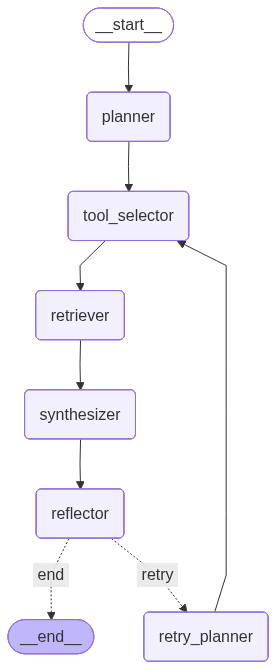

In [14]:

# 13. Visualize Graph

from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [15]:

# 14. Test

test_question = """
How would you build a production-ready AI agent using LangChain, LangGraph,
RAG, and external model providers? Explain the role of each component and how they interact.
"""

result = graph.invoke({
    "question": test_question
})

print("\n========== QUESTION ==========")
print(result["question"])

print("\n========== SUBTASKS ==========")
for task in result["subtasks"]:
    print("-", task)

print("\n========== SELECTED TOOLS ==========")
for task, tool in result["selected_tools"].items():
    print(f"{task} --> {tool}")

print("\n========== RETRIEVED DOCS ==========")
for task, docs in result["retrieved_docs"].items():
    print(f"\n--- {task} ---")
    for i, doc in enumerate(docs, start=1):
        print(f"\nDoc {i}:")
        print(doc[:700])

print("\n========== FINAL ANSWER ==========")
print(result["answer"])

print("\n========== REFLECTION ==========")
print(result["reflection"])

print("\n========== ATTEMPTS ==========")
print(result["attempts"])

KeyboardInterrupt: 